In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

# 1 Discrete Probability Distribution

## Binomial Distribution / Experiment

A **binomial experiment** has the following characteristics:

1. The experiment consists of a **fixed number of trials**, denoted by $n$.
2. Each experiment has only **two possible outcomes**: a **success** or a **failure**.
3. The probability of a **success** and the probability of a **failure** are **constant throughout the experiment**.
4. Each trial is **independent** of the other trials in the experiment.
---

#### Question:

Many wholesale stores offer free samples for customers to taste things in order to increase sales. Let's assume that on a specific day, one wholesale store in Chicago, Illinois, provides a free sample of Parmesan cheese for every customer that walks by the cheese aisle.

Historically, **20% of the customers who sampled the cheese bought a cheese wheel that day**.

One store manager suspected that, so he decided to randomly select **three customers** who sampled the cheese—call them **Bob, Kate, and Roger**.

**What is the probability that one of the customers will buy the Parmesan cheese wheel they sampled that day?**

In [2]:
num_buys = [0, 1, 2, 3]

success_rate = 0.2
n = 3 # number of tials

result = stats.binom.pmf(num_buys,n, success_rate)

df = pd.DataFrame({'num_buyers':num_buys,
                   'probability':result})
df

,num_buyers,probability
0,0,0.512
1,1,0.384
2,2,0.096
3,3,0.008


In [3]:
result2 = stats.binom.cdf(num_buys, n, success_rate)

result2

array([0.512, 0.896, 0.992, 1.   ])

In [4]:
### Q. p = 0.30 only 30% of students go for higher studies, n = 5 students

n = 5
p = 0.30

proba = stats.binom.pmf(np.arange(6), n, p)

cdf_proba = stats.binom.cdf(np.arange(6), n, p)

pd.DataFrame({"x":np.arange(n+1),"proba":proba, "cdf_proba":cdf_proba})

,x,proba,cdf_proba
0,0,0.16807,0.16807
1,1,0.36015,0.52822
2,2,0.30870,0.83692
3,3,0.13230,0.96922
4,4,0.02835,0.99757
5,5,0.00243,1.00000


## Poisson Process

A **Poisson process** has the following characteristics:

1. The experiment consists of **counting the number of occurrences of an event** over a period of time, area, distance, or any other type of measurement.

2. The **mean of the Poisson distribution** has to be the same for each equal interval of measurement.

3. The number of occurrences during one interval is **independent** of the number of occurrences in any other interval.

4. The intervals that are defined in the **Poisson process cannot overlap**.

> **A Poisson process does not count successes and failures like the binomial.**  
> Rather, it counts the **number of occurrences of a particular event** over a specific interval, such as **time or distance**.
---


#### Question
Hair Cuttery notices that some customers **do not show up for their appointments**.

On Saturdays, the salon usually has an average of **4.2 customers who don't show up**.

Because **4.2 is an average**, the actual number of no-show customers on a Saturday can be 0, 1, 2, 3, 4, 5, etc.

We assume that the actual number of no-show customers follows a **Poisson distribution**.

> **What is the probability that Hair Cuttery will have exactly `x` customers who don't show up next Saturday?**

We can use the **Poisson probability distribution** to calculate this probability.


In [5]:
mean = 4.2

result = stats.poisson.pmf(np.arange(6), mean)


pd.DataFrame({
    'no_shows_up':np.arange(6),
    'probability':result.round(3)
})

,no_shows_up,probability
0,0,0.015
1,1,0.063
2,2,0.132
3,3,0.185
4,4,0.194
5,5,0.163


## Hypergeometric Distribution 

>> **The hypergeometric distribution** is used when samples are taken from a **small population without being replaced**.

#### Question

A Pennsylvania retailer currently employs **22 sales associates**, of which **8 are more than 55 years old**. We will refer to these 8 people as the **"older employees."**

Due to a recent downturn in the economy, the retailer decided to **reduce its sales force by 7 employees**. Of the 7 people laid off, **5 were older employees**.

If the employees who were laid off were **randomly selected**, what is the probability that **5 of them would be from the older employee group**?

> **Success** is defined as an older employee being selected to be laid off.

### Important Point

This example involves **sampling without replacement**. Once an employee is selected and laid off, that employee **cannot be selected again**.

Therefore, the probability of selecting an older employee **changes after each selection**.

This makes the **hypergeometric distribution** appropriate for this problem.

### Given

- **Population size:** $N = 22$
- **Number of older employees:** $K = 8$
- **Sample size:** $n = 7$
- **Number of older employees selected:** $x = 5$


In [6]:
N = 22 # Population size
n = 7 #sample size
k = 8 # number of older people
x = 5 # number of older people selected

# result = stats.hypergeom.pmf(np.arange(x+1), N, n, k)

result = stats.hypergeom.pmf(5, N, n, k)

print(result)


0.029880851862276007


> The probability of 5 older employees will get selected is less than 3%

In [7]:
k = 2 # 2 damaged in all 20
n = 5 # sample of 5
N = 20 # total mangoes

x = np.arange(n+1)

proba = stats.hypergeom.pmf(x, N, n, k)
cdf_proba = stats.hypergeom.cdf(x, N, n, k)

pd.DataFrame({"x":x,"proba":proba, "cdf_proba":cdf_proba})

,x,proba,cdf_proba
0,0,0.552632,0.552632
1,1,0.394737,0.947368
2,2,0.052632,1.000000
3,3,0.000000,1.000000
4,4,0.000000,1.000000
5,5,0.000000,1.000000


# 2. Continuous Probability Distribution

## Normal Distribution


A **normal distribution** is a continuous probability distribution with a symmetric, bell-shaped curve.

It is also called the **Gaussian distribution**.

#### Main characteristics

* Bell-shaped and symmetric
* Mean = Median = Mode
* Most observations are close to the mean
* Fewer observations occur farther from the mean
* Total area under the curve = **1 (100%)**

---

#### 2. Mean and Standard Deviation

A normal distribution is mainly described by two parameters:

* **μ (Mean)** → tells us the center/location of the distribution
* **σ (Standard Deviation)** → tells us how spread out the data is

A larger standard deviation means more spread.

A smaller standard deviation means values are more concentrated around the mean.

---

#### 3. Empirical Rule — 68-95-99.7 Rule

For approximately normally distributed data:

| Range  | Percentage of observations |
| ------ | -------------------------: |
| μ ± 1σ |                        68% |
| μ ± 2σ |                        95% |
| μ ± 3σ |                      99.7% |

This is also called the **Empirical Rule**.

---

#### 4. Standard Normal Distribution

The **standard normal distribution** is a special normal distribution where:

* Mean = **0**
* Standard deviation = **1**

It is commonly used to calculate probabilities.

---

#### 5. Z-Score

A **z-score** tells us how many standard deviations an observation is away from the mean.

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

* `x` = observed value
* `μ` = population mean
* `σ` = population standard deviation

- Interpretation

* `z = 0` → value is exactly at the mean
* `z = +1` → 1 SD above the mean
* `z = -1` → 1 SD below the mean
* `z = +2` → 2 SD above the mean
* `z = -2` → 2 SD below the mean

---


> Normal Distribution and Outliers

A common rule of thumb is:

$$
|z| > 3
$$

An observation more than **3 standard deviations** from the mean is considered unusual under a normal model.

However:

> A large z-score does not automatically mean the observation is an error.

It should be investigated.

---

#### Statistical tests

Common tests include:

* Shapiro-Wilk test
* Anderson-Darling test
* D'Agostino's K² test

> Do not rely only on a normality test. Use graphs and statistical knowledge together.

---

#### Normal Distribution in Statistics

Normal distribution is important in:

* Z-tests
* T-tests
* ANOVA
* Regression
* Confidence intervals
* Hypothesis testing
* Statistical inference

An important point:

> Some statistical methods do not require the raw data itself to be perfectly normal. The relevant assumption may instead concern the sampling distribution or model residuals.

---

## 13. Key Difference

### Normal Distribution

Can have:

$$
\mu \neq 0
$$

and

$$
\sigma \neq 1
$$

### Standard Normal Distribution

Always has:

$$
\mu = 0
$$

$$
\sigma = 1
$$

---


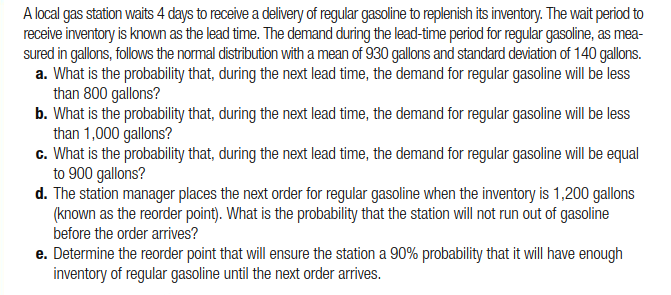

In [18]:
mean = 930
std = 140

#A.
print("Answer 1: ", stats.norm.cdf(800, loc=mean, scale=std))
print("Answer 2: ", stats.norm.cdf(1000, loc=mean, scale=std))
print("Answer 3: Zero because x is continuous")
print("Answer 4: ", stats.norm.cdf(1200, loc=mean, scale=std))
print("Answer 5: ", mean + stats.norm.ppf(0.90)*std)


Answer 1:  0.17655561725300278
Answer 2:  0.6914624612740131
Answer 3: Zero because x is continuous
Answer 4:  0.9731079555688008
Answer 5:  1109.417219176244


## Central Limit Theorem and Condifence Interval
The Central Limit Theorem states that the sample means of large-sized samples will be normally distributed regardless of the shape of their population distributions. 

1. When Population standard deviation is known 
$$ UCL = \bar {x} + z_{\alpha/2} \frac {\sigma}  {\sqrt{n}} $$

In [20]:
mean = 129.20   # Population mean
sample_size = 32
pop_std = 40.60

conf_int = stats.norm.interval(0.90, loc=mean, scale=pop_std/np.sqrt(sample_size))

conf_int

(np.float64(117.39466539018174), np.float64(141.00533460981822))

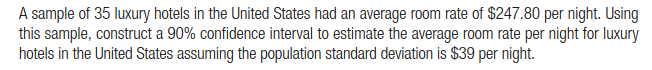

In [21]:
n = 35
mean = 247.80
pop_std = 39

stats.norm.interval(0.90, mean, pop_std/np.sqrt(n))


(np.float64(236.95679067845538), np.float64(258.64320932154465))

1. When Population standard deviation is unknown (Studen's t-Distribution)
$$ UCL = \bar {x} + t_{\alpha/2, df} \frac {s}  {\sqrt{n}} $$

In [22]:
mean = 100.3
std = 16.6
n = 18
stats.t.interval(0.95, loc=mean, scale=std/np.sqrt(n), df=n-1)

(np.float64(92.04501420816446), np.float64(108.55498579183553))

In [24]:
# cost charged by a tax preparation service
data = np.array([135,120,150,110,90,115,130,200,180,200,140,150,100,75,70])

# a. Using a 98% confidence interval, estimate the average cost of the service for preparing a tax return for a customer.
# b. What is the margin of error for this sample? 

res_a = stats.t.interval(confidence=0.98, df=len(data)-1,
                        loc=data.mean(), scale=stats.sem(data))
res_a

(np.float64(103.49791629579052), np.float64(158.5020837042095))

In [25]:
data = np.array([356,275,371,384,457,326,
                414,367,362,286,104,136,
                320,244,370,215,322,409,
                303,489,251,361,337,265])

avg_domestic_fare = stats.t.interval(confidence=0.99, df=len(data)-1,
                                    loc=data.mean(), scale=stats.sem(data))
avg_domestic_fare

(np.float64(269.87984899817843), np.float64(373.7868176684882))

In [27]:
margin_of_error = data.mean() - avg_domestic_fare[0]
margin_of_error

np.float64(51.95348433515488)

In [28]:
dataframe = pd.DataFrame({'month':['jan','feb','mar','apr','may','jun'],
                         'stock_price':[71,73,76,78,81,75]})

mean = dataframe.stock_price.mean()
std = dataframe.stock_price.std()

## 90% confidence interval
stats.t.interval(0.90, df=len(dataframe)-1,
                 loc=mean,
                 scale=stats.sem(dataframe.stock_price))

(np.float64(72.73886925809845), np.float64(78.5944640752349))